# DD — Foundation Analysis Notebook
**Data science jobs · skill traits · personality traits — the common baseline that every problem statement needs**

This notebook runs the analysis layers that are useful *whichever* objective you finally choose. It starts from file import and ends with exported, analysis-ready tables.

| # | Layer | What it produces |
|---|---|---|
| 1 | Setup and import | Files loaded (upload prompt in Colab) |
| 2 | Structural audit | Types, missingness, duplicates, key checks, domain-rule checks |
| 3 | Treatment policy | Documented, switchable rules to build analysis-ready frames |
| 4 | Feature derivation | Seniority, role family, skill flags, composites, salary midpoints |
| 5 | Univariate | Distributions, skew, outliers, normality, category frequencies |
| 6 | Bivariate | Outcome comparisons (effect sizes, tests), correlations, salary drivers |
| 7 | Consolidation (bridge layer) | Construct-level tables that connect the four files without keys |
| 8 | Multivariate | PCA and clustering of skill and personality profiles |
| 9 | Predictive baselines | Cross-validated models, importances, sensitivity checks |
| 10 | Export | CSVs, figures, zip |

**Important modelling notes**
- None of the four files can be joined row-by-row. IDs are *not* unique even inside a file, and numeric overlaps between files are coincidental (checked in section 2). All linkage is at segment or construct level.
- `salary_hike_high_or_low` and `success_classification_high_low` are assumed to be coded **1 = high, 0 = low** (the group means in section 6 confirm the direction).
- Every result is associational, from small single-company samples (JDS, SDS) and sampled postings (job files).

## 1. Setup and file import

In [1]:
import os, re, shutil, warnings
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

RANDOM_STATE = 42
OUT_DIR = 'outputs'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------- switches you may change, then re-run from here ----------------
JUNIOR_MAX_YRS  = 3      # min experience <= this  -> "Junior" bucket (job files)
SENIOR_MIN_YRS  = 8      # min experience >= this  -> "Senior" bucket (Analytics file)
DEDUP_ANALYTICS = True   # drop exact duplicate postings from the Analytics core set
# --------------------------------------------------------------------------------

FILES = {
    'jds': 'JDS_Skill_Traits_clean.csv',
    'sds': 'SDS_Personality_Traits_clean.csv',
    'dsj': 'DataScience_Jobs_clean.csv',
    'an' : 'Analytics_Jobs_clean.csv',
}
JDS_SKILLS = ['big_data_skills', 'maths_stats_skills', 'coding_skills',
              'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
SDS_TRAITS = ['neuroticism', 'extraversion', 'openness_to_experience',
              'agreeableness', 'conscientiousness']

pretty = lambda s: s.replace('_skills', '').replace('_and_', ' & ').replace('_', ' ')

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [3]:
# ---- locate the four CSVs; in Colab, prompt for upload if they are not already there ----
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Optional: to read from Google Drive instead of uploading, uncomment:
# from google.colab import drive; drive.mount('/content/drive')

SEARCH_DIRS = ['.', 'data', '/content', '/content/drive/MyDrive', '/mnt/project']

def locate(fname):
    for d in SEARCH_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

missing = [f for f in FILES.values() if locate(f) is None]
if missing and IN_COLAB:
    print('Please select these files in the upload dialog:\n  ' + '\n  '.join(missing))
    colab_files.upload()          # files land in the current working directory

paths = {k: locate(v) for k, v in FILES.items()}
still_missing = [FILES[k] for k, p in paths.items() if p is None]
assert not still_missing, f'Files not found: {still_missing}. Upload them or fix SEARCH_DIRS.'

jds = pd.read_csv(paths['jds'])
sds = pd.read_csv(paths['sds'])
dsj = pd.read_csv(paths['dsj'])
an  = pd.read_csv(paths['an'])

for name, df in [('JDS (junior skills)', jds), ('SDS (senior personality)', sds),
                 ('DataScience Jobs', dsj), ('Analytics Jobs', an)]:
    print(f'{name:28s} {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols')

Please select these files in the upload dialog:
  SDS_Personality_Traits_clean.csv
  DataScience_Jobs_clean.csv
  Analytics_Jobs_clean.csv


Saving SDS_Personality_Traits_clean.csv to SDS_Personality_Traits_clean.csv
Saving JDS_Skill_Traits_clean.csv to JDS_Skill_Traits_clean (1).csv
Saving DataScience_Jobs_clean.csv to DataScience_Jobs_clean.csv
Saving Analytics_Jobs_clean.csv to Analytics_Jobs_clean.csv
JDS (junior skills)              139 rows x 11 cols
SDS (senior personality)         161 rows x 11 cols
DataScience Jobs               1,602 rows x 13 cols
Analytics Jobs                14,839 rows x 19 cols


## 2. Structural audit
Per file: types, missingness, cardinality, the pre-computed `flag_*` columns, duplicates, key behaviour, and domain-rule checks.

In [4]:
def audit(df, name):
    print('=' * 90)
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
    prof = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'n_unique': df.nunique(),
    })
    display(prof)
    flag_cols = [c for c in df.columns if c.startswith('flag_')]
    if flag_cols:
        fl = df[flag_cols].sum().to_frame('rows_flagged')
        fl['pct_of_rows'] = fl['rows_flagged'] / len(df) * 100
        print('Pre-computed quality flags:')
        display(fl)

audit(jds, 'JDS_Skill_Traits')
audit(sds, 'SDS_Personality_Traits')
audit(dsj, 'DataScience_Jobs')
audit(an,  'Analytics_Jobs')

JDS_Skill_Traits: 139 rows x 11 columns


,dtype,non_null,missing_pct,n_unique
record_no,int64,139,0.000,139
id,int64,139,0.000,137
big_data_skills,float64,139,0.000,28
maths_stats_skills,float64,139,0.000,27
coding_skills,float64,139,0.000,22
ai_and_ml_skills,float64,139,0.000,22
dashboard_and_storytelling_skills,float64,139,0.000,21
salary_hike_high_or_low,int64,139,0.000,2
flag_id_collision,int64,139,0.000,2
flag_repeat_score_profile,int64,139,0.000,2


Pre-computed quality flags:


,rows_flagged,pct_of_rows
flag_id_collision,4,2.878
flag_repeat_score_profile,21,15.108
flag_outlier_z3,2,1.439


SDS_Personality_Traits: 161 rows x 11 columns


...

,rows_flagged,pct_of_rows
flag_ref_no_collision,276,17.228
flag_placeholder_company,7,0.437
flag_outlier_avg_salary,1,0.062
flag_outlier_num_of_jobs,10,0.624


Analytics_Jobs: 14,839 rows x 19 columns


,dtype,non_null,missing_pct,n_unique
s_no,int64,14839,0.000,14839
job_desig,object,14839,0.000,10088
job_description,object,11468,22.717,7836
job_type,object,3273,77.943,1
key_skills,object,14834,0.034,11139
experience,object,14839,0.000,128
exp_min_yrs,int64,14839,0.000,22
exp_max_yrs,int64,14839,0.000,29
salary,object,14839,0.000,6
salary_min_lpa,int64,14839,0.000,6


Pre-computed quality flags:


,rows_flagged,pct_of_rows
flag_pan_india,86,0.580
flag_international,245,1.651
flag_skills_truncated,12906,86.974
flag_gig_or_data_entry_posting,89,0.600


In [5]:
# ---- duplicates, key behaviour, and proof that the files are not relationally linked ----
DEDUP_COLS = ['job_desig', 'job_description', 'key_skills', 'experience', 'salary', 'location_raw']
dsj_content_cols = [c for c in dsj.columns if c not in ('record_no', 'reference_no') and not c.startswith('flag_')]

dups = pd.Series({
    'JDS duplicate score rows (ignoring id)': int(jds.duplicated(subset=JDS_SKILLS + ['salary_hike_high_or_low']).sum()),
    'SDS duplicate score rows (ignoring id)': int(sds.duplicated(subset=SDS_TRAITS + ['success_classification_high_low']).sum()),
    'DSJ duplicate rows (ignoring reference_no)': int(dsj.duplicated(subset=dsj_content_cols).sum()),
    'Analytics duplicate postings': int(an.duplicated(subset=DEDUP_COLS).sum()),
    'Analytics duplicates if salary band is ignored (info only)': int(an.duplicated(subset=[c for c in DEDUP_COLS if c != 'salary']).sum()),
}).to_frame('rows')
display(dups)

keys = pd.DataFrame({
    'rows':       [len(jds), len(sds), len(dsj), len(an)],
    'distinct':   [jds.id.nunique(), sds.id.nunique(), dsj.reference_no.nunique(), an.s_no.nunique()],
    'min':        [jds.id.min(), sds.id.min(), dsj.reference_no.min(), an.s_no.min()],
    'max':        [jds.id.max(), sds.id.max(), dsj.reference_no.max(), an.s_no.max()],
}, index=['JDS.id', 'SDS.id', 'DSJ.reference_no', 'Analytics.s_no'])
keys['is_unique_key'] = keys.rows == keys.distinct
print('\nCandidate key columns:')
display(keys)

id_sets = {'JDS.id': set(jds.id), 'SDS.id': set(sds.id), 'DSJ.reference_no': set(dsj.reference_no)}
overlap = [{'pair': f'{a} x {b}', 'shared_values': len(id_sets[a] & id_sets[b])} for a, b in combinations(id_sets, 2)]
print('\nNumeric overlap between ID columns across files (coincidental, NOT a join):')
display(pd.DataFrame(overlap))
print('Note: many Analytics postings are identical except for the salary band; they are kept (treated as distinct) because only fully identical rows are dropped.')
print('Conclusion: IDs repeat within files and mean different things across files -> use record_no / s_no as row labels only; link at construct level.')

,rows
JDS duplicate score rows (ignoring id),21
SDS duplicate score rows (ignoring id),0
DSJ duplicate rows (ignoring reference_no),0
Analytics duplicate postings,1
Analytics duplicates if salary band is ignored (info only),2767



Candidate key columns:


,rows,distinct,min,max,is_unique_key
JDS.id,139,137,2007,4000,False
SDS.id,161,152,8001,8979,False
DSJ.reference_no,1602,1460,1012,8998,False
Analytics.s_no,14839,14839,1,15841,True



Numeric overlap between ID columns across files (coincidental, NOT a join):


,pair,shared_values
0,JDS.id x SDS.id,0
1,JDS.id x DSJ.reference_no,21
2,SDS.id x DSJ.reference_no,33


Note: many Analytics postings are identical except for the salary band; they are kept (treated as distinct) because only fully identical rows are dropped.
Conclusion: IDs repeat within files and mean different things across files -> use record_no / s_no as row labels only; link at construct level.


In [6]:
# ---- domain-rule checks ----
checks = {
    'JDS: skill scores outside 1-5':                int(((jds[JDS_SKILLS] < 1) | (jds[JDS_SKILLS] > 5)).any(axis=1).sum()),
    'SDS: trait value range (min .. max)':          f'{sds[SDS_TRAITS].min().min()} .. {sds[SDS_TRAITS].max().max()}',
    'JDS/SDS: outcome not in {0,1}':                int((~jds.salary_hike_high_or_low.isin([0, 1])).sum() + (~sds.success_classification_high_low.isin([0, 1])).sum()),
    'DSJ: avg outside [min, max] salary':           int(((dsj.avg_salary_lpa < dsj.min_salary_lpa) | (dsj.avg_salary_lpa > dsj.max_salary_lpa)).sum()),
    'DSJ: negative experience':                     int((dsj.min_experience < 0).sum()),
    'Analytics: exp_min > exp_max':                 int((an.exp_min_yrs > an.exp_max_yrs).sum()),
    'Analytics: salary_min > salary_max':           int((an.salary_min_lpa > an.salary_max_lpa).sum()),
    'Analytics: job_description missing (%)':       round(an.job_description.isna().mean() * 100, 1),
    'Analytics: key_skills flagged truncated (%)':  round(an.flag_skills_truncated.mean() * 100, 1),
    'Analytics: gig / data-entry postings':         int(an.flag_gig_or_data_entry_posting.sum()),
}
display(pd.Series(checks).to_frame('result'))

,result
JDS: skill scores outside 1-5,0
SDS: trait value range (min .. max),17 .. 68
"JDS/SDS: outcome not in {0,1}",0
"DSJ: avg outside [min, max] salary",0
DSJ: negative experience,0
Analytics: exp_min > exp_max,0
Analytics: salary_min > salary_max,0
Analytics: job_description missing (%),22.700
Analytics: key_skills flagged truncated (%),87.000
Analytics: gig / data-entry postings,89


## 3. Treatment policy — building the analysis-ready ("core") frames
Rules are deliberately conservative and documented, because the brief rewards visible data-issue handling.

| File | Treatment | Reason |
|---|---|---|
| JDS, SDS | Keep all rows; sensitivity checks later (section 9) | Repeated IDs are *different* rows, so they are not dropped; the samples are too small to lose rows without evidence |
| DataScience Jobs | Drop placeholder companies (`Confidential`, `N+A`, `Data Entry`) | Not real employers; distorts company-level views |
| DataScience Jobs | Keep large-volume outliers (TCS, IBM...) but analyse `num_of_jobs` on a log scale | They are genuine mega-recruiters, not errors |
| Analytics Jobs | Drop gig / data-entry postings | Off-topic for data careers |
| Analytics Jobs | Drop exact duplicate postings (switch `DEDUP_ANALYTICS`) | Avoids double-counting skills demand |

In [7]:
jds_core = jds.copy()
sds_core = sds.copy()
dsj_core = dsj[dsj.flag_placeholder_company == 0].copy()

an = an.copy()
an['flag_duplicate_posting'] = an.duplicated(subset=DEDUP_COLS, keep='first').astype(int)
an_mask = an.flag_gig_or_data_entry_posting == 0
if DEDUP_ANALYTICS:
    an_mask &= an.flag_duplicate_posting == 0
an_core = an[an_mask].copy()

treat = pd.DataFrame({
    'rows_in':   [len(jds), len(sds), len(dsj), len(an)],
    'rows_core': [len(jds_core), len(sds_core), len(dsj_core), len(an_core)],
}, index=['JDS', 'SDS', 'DataScience Jobs', 'Analytics Jobs'])
treat['rows_removed'] = treat.rows_in - treat.rows_core
treat['pct_removed'] = treat.rows_removed / treat.rows_in * 100
display(treat)

,rows_in,rows_core,rows_removed,pct_removed
JDS,139,139,0,0.000
SDS,161,161,0,0.000
DataScience Jobs,1602,1595,7,0.437
Analytics Jobs,14839,14749,90,0.607


## 4. Feature derivation
The derived fields below create the shared vocabulary (seniority, role family, five skill dimensions) used to link the files later.

Skill dimensions in the Analytics file come from keyword dictionaries applied to title + key skills + description. They are **proxies**, and because most `key_skills` strings are truncated, prevalence figures are lower bounds.

In [8]:
# ---------------- JDS ----------------
jds_core['outcome']      = jds_core.salary_hike_high_or_low.map({1: 'High hike', 0: 'Low hike'})
jds_core['tech_mean']    = jds_core[JDS_SKILLS].mean(axis=1)
jds_core['skill_spread'] = jds_core[JDS_SKILLS].std(axis=1)          # low = balanced profile
jds_core['n_skills_ge4'] = (jds_core[JDS_SKILLS] >= 4).sum(axis=1)

# ---------------- SDS ----------------
sds_core['outcome'] = sds_core.success_classification_high_low.map({1: 'High success', 0: 'Low success'})
for c in SDS_TRAITS:
    sds_core[f'z_{c}'] = (sds_core[c] - sds_core[c].mean()) / sds_core[c].std()
good_traits = ['extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']
sds_core['n_traits_above_median'] = sum((sds_core[c] > sds_core[c].median()).astype(int) for c in good_traits)

# ---------------- DataScience Jobs ----------------
dsj_core['role_family']     = dsj_core.job_title.str.replace(r'^Senior ', '', regex=True)
dsj_core['is_senior_title'] = (dsj_core.job_title.str.startswith('Senior') | (dsj_core.job_title == 'Data Architect')).astype(int)
dsj_core['seniority']       = np.where(dsj_core.is_senior_title == 1, 'Senior', 'Junior/Mid')
dsj_core['salary_spread']   = dsj_core.max_salary_lpa - dsj_core.min_salary_lpa
dsj_core['log_jobs']        = np.log1p(dsj_core.num_of_jobs)
company_openings            = dsj_core.groupby('company_name').num_of_jobs.transform('sum')
dsj_core['large_recruiter'] = (company_openings >= company_openings.quantile(0.90)).astype(int)

# ---------------- Analytics Jobs ----------------
an_core['salary_mid'] = (an_core.salary_min_lpa + an_core.salary_max_lpa) / 2
an_core['exp_mid']    = (an_core.exp_min_yrs + an_core.exp_max_yrs) / 2
an_core['seniority']  = np.select([an_core.exp_min_yrs <= JUNIOR_MAX_YRS, an_core.exp_min_yrs >= SENIOR_MIN_YRS],
                                  ['Junior', 'Senior'], default='Mid')

def role_family(title):
    t = str(title).lower()
    if 'data scien' in t:                                              return 'Data Scientist'
    if re.search(r'machine learning|\bml\b|\bai\b|deep learning|nlp', t): return 'ML/AI Engineer'
    if re.search(r'data engineer|\betl\b|big data|hadoop|data warehouse|\bdwh\b', t): return 'Data Engineer'
    if 'architect' in t:                                               return 'Architect'
    if re.search(r'analyst|analytics', t):                             return 'Analyst'
    if re.search(r'consultant|manager|lead|head|director', t):         return 'Consultant/Manager'
    if re.search(r'developer|software|engineer|programmer', t):        return 'Software/IT'
    return 'Other'

an_core['role_family']      = an_core.job_desig.map(role_family)
CORE_ROLES                  = ['Data Scientist', 'ML/AI Engineer', 'Data Engineer', 'Architect', 'Analyst']
an_core['is_core_data_role'] = an_core.role_family.isin(CORE_ROLES).astype(int)

SKILL_PATTERNS = {
    'big_data_skills':    r'hadoop|spark|big data|bigdata|\bhive\b|kafka|hbase|nosql|mapreduce|data lake|databricks|cloudera',
    'maths_stats_skills': r'statistic|regression|forecast|probabilit|mathemat|hypothesis|quantitative|time series|bayes|optimi[sz]ation|\bsas\b|\bspss\b',
    'coding_skills':      r'python|\bjava\b|scala|\bsql\b|programming|c\+\+|pyspark|\bperl\b|javascript|coding',
    'ai_and_ml_skills':   r'machine learning|\bml\b|deep learning|artificial intelligence|\bai\b|\bnlp\b|natural language|neural|tensorflow|pytorch|computer vision|data mining|predictive model',
    'dashboard_and_storytelling_skills': r'tableau|power ?bi|dashboard|visuali[sz]|qlik|storytelling|data story|reporting|cognos|looker',
}
text_all = (an_core.job_desig.fillna('') + ' ' + an_core.key_skills.fillna('') + ' ' + an_core.job_description.fillna('')).str.lower()
for k, pat in SKILL_PATTERNS.items():
    an_core[f'skill_{k}'] = text_all.str.contains(pat, regex=True).astype(int)
an_core['n_skill_dims'] = an_core[[f'skill_{k}' for k in SKILL_PATTERNS]].sum(axis=1)

METROS = ['Bengaluru', 'Mumbai', 'Delhi NCR', 'Gurgaon', 'Noida', 'Pune', 'Hyderabad', 'Chennai', 'Kolkata']
an_core['is_metro']       = an_core.primary_location.isin(METROS).astype(int)
top_locs                  = an_core.primary_location.value_counts().head(8).index
an_core['location_group'] = np.where(an_core.primary_location.isin(top_locs), an_core.primary_location, 'Other')
an_core['desc_missing']   = an_core.job_description.isna().astype(int)

print('Role family (Analytics core):')
display(an_core.role_family.value_counts().to_frame('postings'))
print('Skill-dimension prevalence (share of postings):')
display(an_core[[f'skill_{k}' for k in SKILL_PATTERNS]].mean().rename(lambda s: pretty(s.replace('skill_', ''))).to_frame('share'))

Role family (Analytics core):


,postings
role_family,
Analyst,4007
Other,3942
Consultant/Manager,3726
Software/IT,1631
Data Engineer,446
Data Scientist,439
Architect,357
ML/AI Engineer,201


Skill-dimension prevalence (share of postings):


,share
big data,0.056
maths stats,0.128
coding,0.240
ai & ml,0.076
dashboard & storytelling,0.071


## 5. Univariate analysis

JDS skill scores


,count,mean,std,min,median,max,skew,kurtosis,iqr_outliers
big_data_skills,139.000,3.850,0.847,2.300,3.800,5.000,-0.081,-1.215,0
maths_stats_skills,139.000,4.294,0.844,2.200,4.600,5.000,-0.973,-0.290,0
coding_skills,139.000,4.268,0.893,2.200,4.600,5.000,-0.890,-0.675,0
ai_and_ml_skills,139.000,4.566,0.667,2.200,4.900,5.000,-1.705,1.994,18
dashboard_and_storytelling_skills,139.000,4.355,0.933,2.300,5.000,5.000,-1.079,-0.479,0


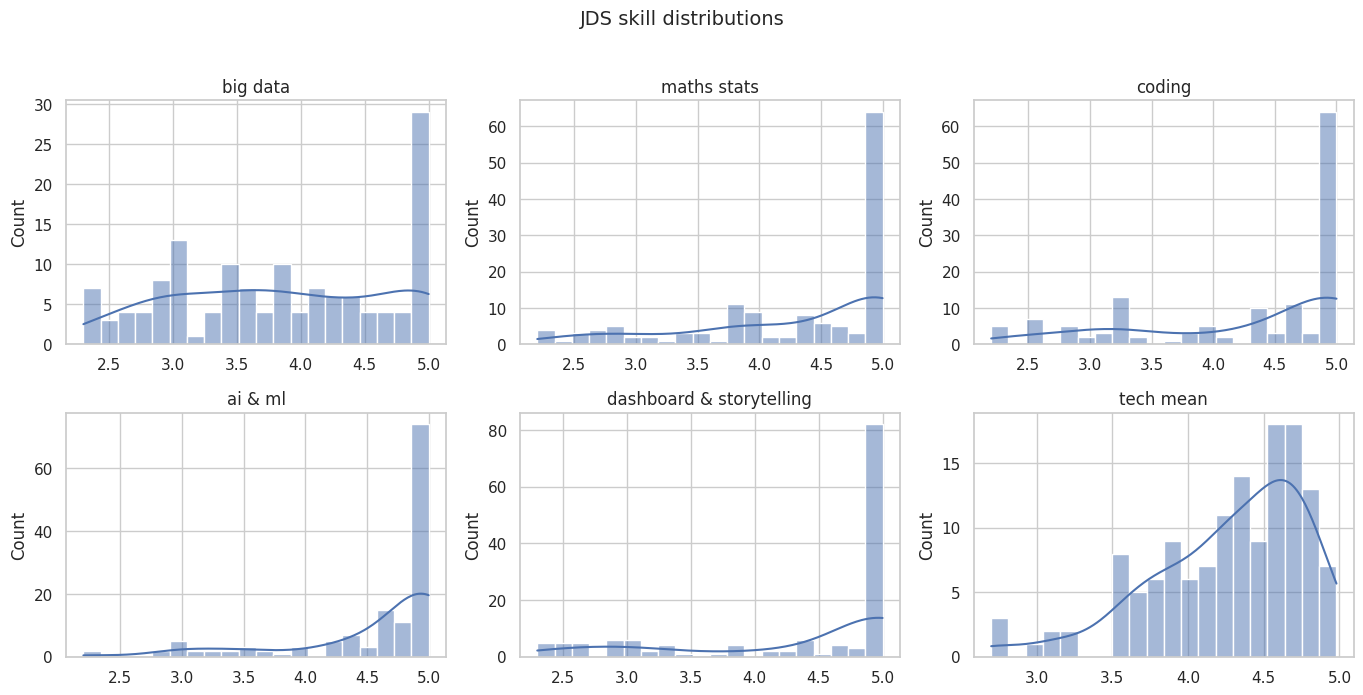

SDS personality traits


,count,mean,std,min,median,max,skew,kurtosis,iqr_outliers
neuroticism,161.000,36.193,11.268,17.000,34.000,68.000,0.722,0.095,0
extraversion,161.000,43.205,12.135,17.000,45.000,67.000,-0.318,-0.740,0
openness_to_experience,161.000,41.329,11.322,18.000,44.000,65.000,-0.381,-0.702,0
agreeableness,161.000,44.602,11.293,17.000,46.000,68.000,-0.442,-0.187,5
conscientiousness,161.000,45.211,13.212,18.000,49.000,66.000,-0.534,-0.954,0


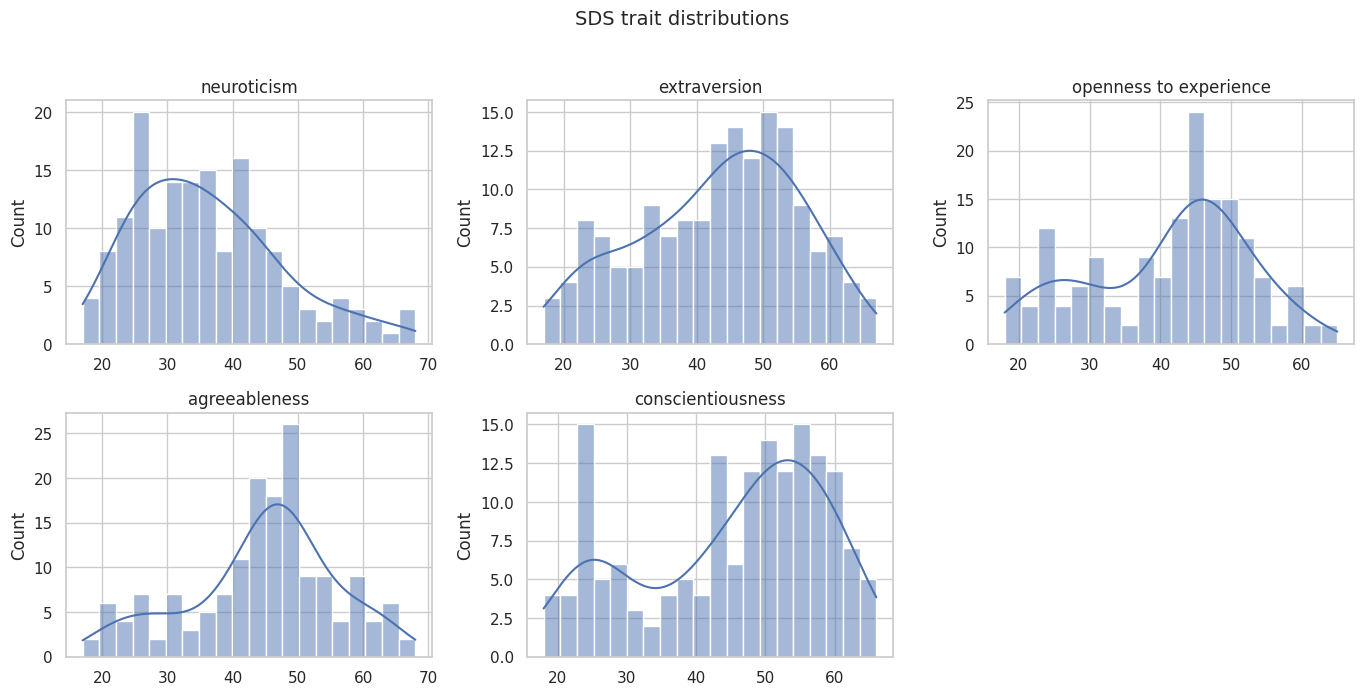

In [9]:
def numeric_summary(df, cols):
    out = df[cols].agg(['count', 'mean', 'std', 'min', 'median', 'max']).T
    out['skew'] = df[cols].skew()
    out['kurtosis'] = df[cols].kurt()
    q1, q3 = df[cols].quantile(.25), df[cols].quantile(.75)
    iqr = q3 - q1
    out['iqr_outliers'] = ((df[cols] < q1 - 1.5 * iqr) | (df[cols] > q3 + 1.5 * iqr)).sum()
    return out

def hist_grid(df, cols, title, ncols=3, bins=20, name=None):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        sns.histplot(df[c].dropna(), bins=bins, kde=True, ax=ax)
        ax.set_title(pretty(c))
        ax.set_xlabel('')
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02, fontsize=14)
    savefig(name or title.lower().replace(' ', '_'))

def freq(df, col, n=10):
    vc = df[col].value_counts(dropna=False).head(n).to_frame('count')
    vc['pct'] = vc['count'] / len(df) * 100
    return vc

print('JDS skill scores'); display(numeric_summary(jds_core, JDS_SKILLS))
hist_grid(jds_core, JDS_SKILLS + ['tech_mean'], 'JDS skill distributions')
print('SDS personality traits'); display(numeric_summary(sds_core, SDS_TRAITS))
hist_grid(sds_core, SDS_TRAITS, 'SDS trait distributions')

In [10]:
# ---- normality: decides parametric vs non-parametric tests for the small trait files ----
norm_rows = []
for df, cols, tag in [(jds_core, JDS_SKILLS, 'JDS'), (sds_core, SDS_TRAITS, 'SDS')]:
    for c in cols:
        w, p = stats.shapiro(df[c])
        norm_rows.append({'file': tag, 'variable': c, 'shapiro_W': w, 'p_value': p, 'normal_at_5pct': p > 0.05})
display(pd.DataFrame(norm_rows))
print('Skills are capped at 5 and left-skewed, so rank-based tests (Mann-Whitney, Spearman) are used from here on.')

,file,variable,shapiro_W,p_value,normal_at_5pct
0,JDS,big_data_skills,0.931,0.000,False
1,JDS,maths_stats_skills,0.808,0.000,False
2,JDS,coding_skills,0.788,0.000,False
3,JDS,ai_and_ml_skills,0.700,0.000,False
4,JDS,dashboard_and_storytelling_skills,0.701,0.000,False
5,SDS,neuroticism,0.956,0.000,False
6,SDS,extraversion,0.971,0.002,False
7,SDS,openness_to_experience,0.956,0.000,False
8,SDS,agreeableness,0.966,0.000,False
9,SDS,conscientiousness,0.921,0.000,False


Skills are capped at 5 and left-skewed, so rank-based tests (Mann-Whitney, Spearman) are used from here on.


DataScience Jobs (core)


,count,mean,std,min,median,max,skew,kurtosis,iqr_outliers
min_experience,"1,595.000",2.809,2.354,0.000,2.000,21.000,1.764,5.603,39
avg_salary_lpa,"1,595.000",13.265,7.843,1.400,11.900,82.000,1.734,7.427,39
min_salary_lpa,"1,595.000",8.659,5.797,0.200,7.000,55.000,1.551,4.089,49
max_salary_lpa,"1,595.000",19.178,11.157,2.000,18.000,102.000,2.404,12.736,40
num_of_jobs,"1,595.000",58.185,169.399,3.000,22.000,"4,200.000",12.771,250.007,163
salary_spread,"1,595.000",10.519,8.021,0.000,9.300,91.000,3.782,26.993,47


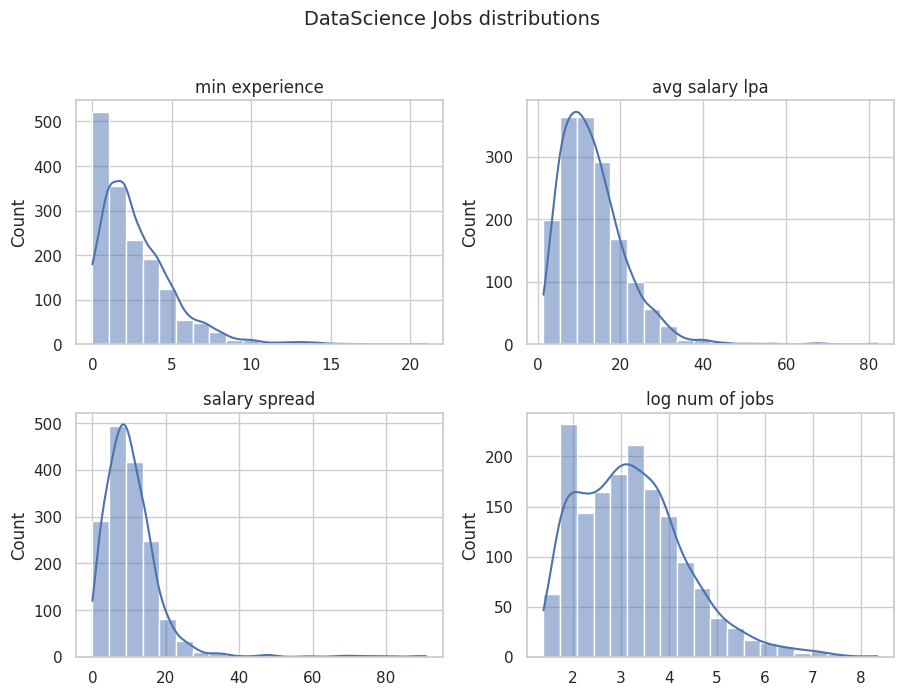

Analytics Jobs (core)


,count,mean,std,min,median,max,skew,kurtosis,iqr_outliers
exp_min_yrs,"14,749.000",4.243,3.294,0.000,3.000,23.000,1.065,1.094,270
exp_max_yrs,"14,749.000",7.968,4.198,0.000,7.000,30.000,1.043,1.680,549
salary_min_lpa,"14,749.000",8.553,6.682,0.000,6.000,25.000,0.734,0.160,0
salary_max_lpa,"14,749.000",15.065,11.922,3.000,10.000,50.000,1.553,2.281,0
salary_mid,"14,749.000",11.809,9.256,1.500,8.000,37.500,1.257,1.429,0
num_locations,"14,749.000",1.230,0.731,1.000,1.000,9.000,5.083,35.274,2041


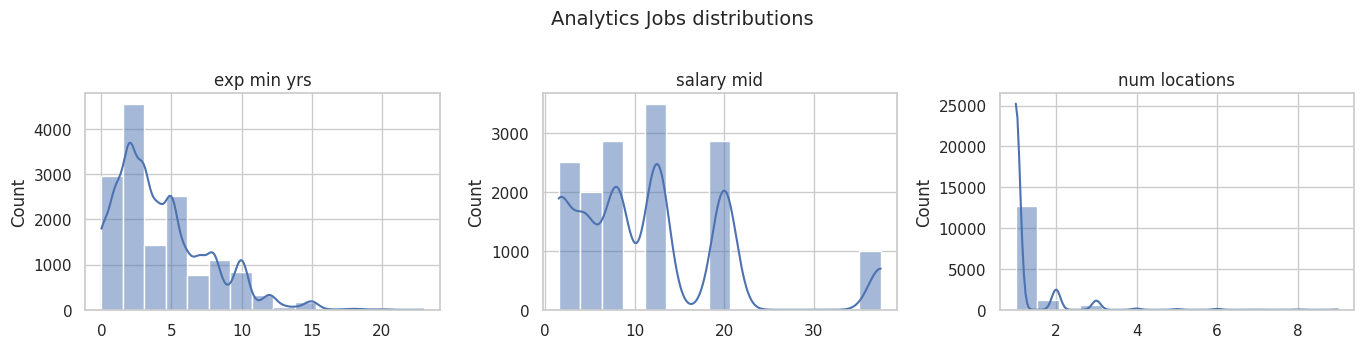

In [11]:
dsj_num = ['min_experience', 'avg_salary_lpa', 'min_salary_lpa', 'max_salary_lpa', 'num_of_jobs', 'salary_spread']
print('DataScience Jobs (core)'); display(numeric_summary(dsj_core, dsj_num))
hist_grid(dsj_core.assign(log_num_of_jobs=dsj_core.log_jobs), ['min_experience', 'avg_salary_lpa', 'salary_spread', 'log_num_of_jobs'],
          'DataScience Jobs distributions', ncols=2)

an_num = ['exp_min_yrs', 'exp_max_yrs', 'salary_min_lpa', 'salary_max_lpa', 'salary_mid', 'num_locations']
print('Analytics Jobs (core)'); display(numeric_summary(an_core, an_num))
hist_grid(an_core, ['exp_min_yrs', 'salary_mid', 'num_locations'], 'Analytics Jobs distributions', bins=15)

DataScience Jobs: titles


,count,pct
job_title,,
Data Engineer,188,11.787
Senior Business Analyst,187,11.724
Senior Data Analyst,187,11.724
Data Scientist,186,11.661
Business Analyst,186,11.661
Data Analyst,185,11.599
Senior Data Scientist,185,11.599
Senior Data Engineer,183,11.473
Machine Learning Engineer,58,3.636


DataScience Jobs: top companies by number of rows


,count,pct
company_name,,
TCS,10,0.627
Accenture,10,0.627
DXC Technology,10,0.627
UST,10,0.627
JP Morgan Chase,10,0.627
IBM,10,0.627
Infosys,10,0.627
Wipro,10,0.627


Analytics: seniority


,count,pct
seniority,,
Junior,7509,50.912
Mid,4713,31.955
Senior,2527,17.133


Analytics: salary band


,count,pct
salary,,
10to15,3503,23.751
6to10,2874,19.486
15to25,2873,19.479
0to3,2505,16.984
3to6,2003,13.581
25to50,991,6.719


Analytics: primary location (top 10)


,count,pct
primary_location,,
Bengaluru,3813,25.853
Mumbai,2401,16.279
Gurgaon,1533,10.394
Delhi NCR,1271,8.618
Pune,1082,7.336
Hyderabad,983,6.665
Chennai,971,6.583
Noida,542,3.675
Delhi,302,2.048


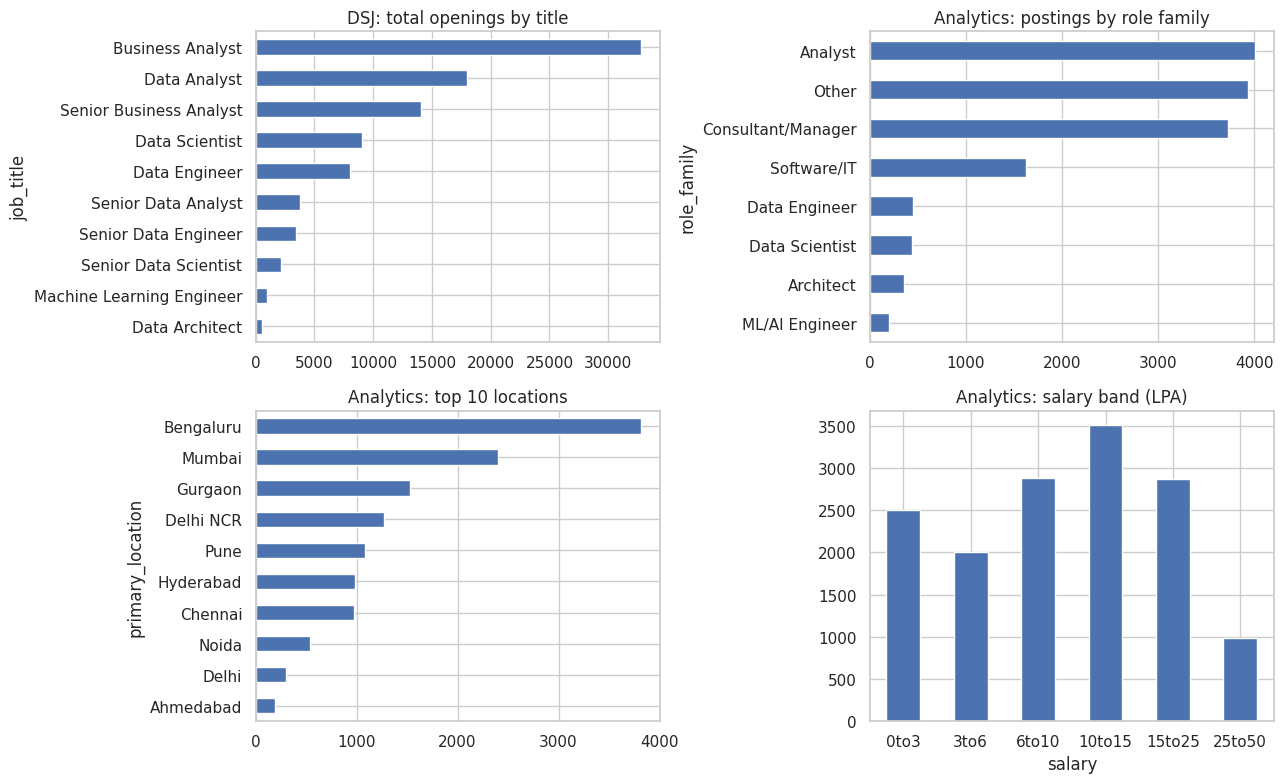

In [12]:
# ---- categorical frequencies ----
print('DataScience Jobs: titles');  display(freq(dsj_core, 'job_title'))
print('DataScience Jobs: top companies by number of rows'); display(freq(dsj_core, 'company_name', 8))
print('Analytics: seniority');      display(freq(an_core, 'seniority'))
print('Analytics: salary band');    display(freq(an_core, 'salary'))
print('Analytics: primary location (top 10)'); display(freq(an_core, 'primary_location', 10))

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
dsj_core.groupby('job_title').num_of_jobs.sum().sort_values().plot.barh(ax=ax[0, 0], title='DSJ: total openings by title')
an_core.role_family.value_counts().sort_values().plot.barh(ax=ax[0, 1], title='Analytics: postings by role family')
an_core.primary_location.value_counts().head(10).sort_values().plot.barh(ax=ax[1, 0], title='Analytics: top 10 locations')
band_order = ['0to3', '3to6', '6to10', '10to15', '15to25', '25to50']
an_core.salary.value_counts().reindex(band_order).plot.bar(ax=ax[1, 1], title='Analytics: salary band (LPA)', rot=0)
savefig('categorical_overview')

## 6. Bivariate analysis
**6a / 6b** compare high vs low outcome groups on skills (JDS) and personality (SDS) with tests and effect sizes.
**6c / 6d** explain salary in the two job files.

JDS: skills of high vs low salary-hike juniors


,mean_high,mean_low,diff,cohens_d,auc_single,p_value,p_bonferroni,significant_5pct
feature,,,,,,,,
dashboard_and_storytelling_skills,4.845,3.814,1.032,1.302,0.794,0.000,0.000,True
maths_stats_skills,4.712,3.830,0.882,1.202,0.775,0.000,0.000,True
coding_skills,4.644,3.853,0.791,0.976,0.744,0.000,0.000,True
ai_and_ml_skills,4.822,4.283,0.539,0.863,0.682,0.000,0.000,True
big_data_skills,3.940,3.750,0.190,0.223,0.561,0.217,1.000,False


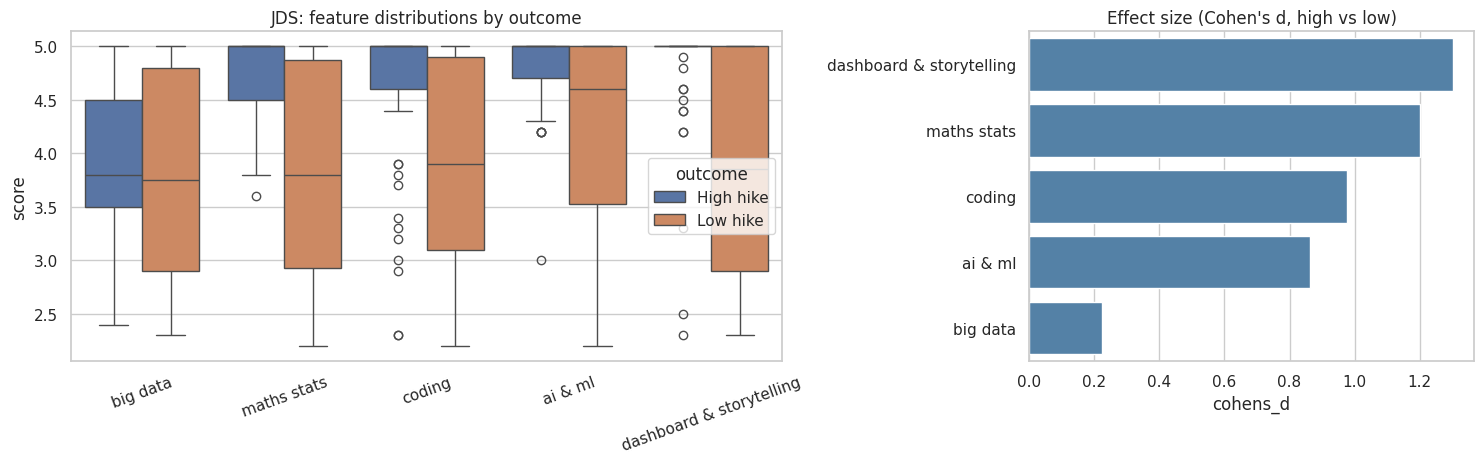

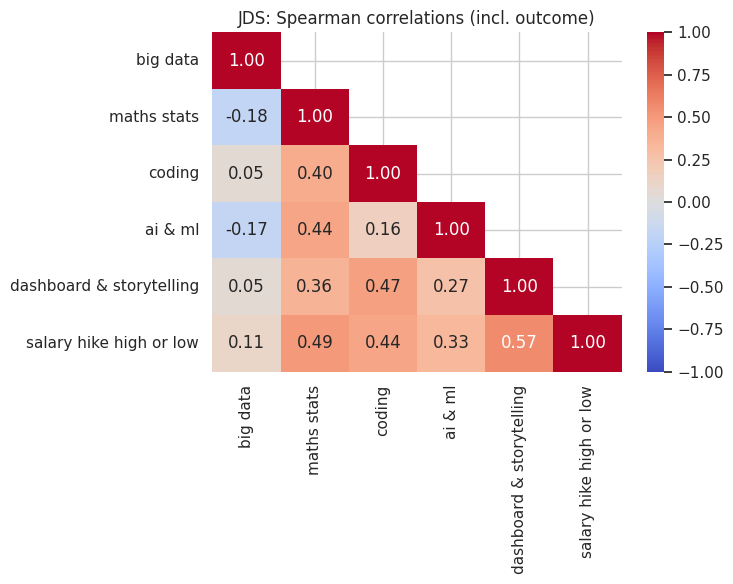

In [13]:
def group_compare(df, cols, target):
    """High (1) vs Low (0): means, Mann-Whitney p (Bonferroni-adjusted), Cohen's d, AUC-style effect."""
    rows = []
    for c in cols:
        g1, g0 = df.loc[df[target] == 1, c], df.loc[df[target] == 0, c]
        u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
        pooled = np.sqrt((g1.var(ddof=1) + g0.var(ddof=1)) / 2)
        rows.append({'feature': c, 'mean_high': g1.mean(), 'mean_low': g0.mean(),
                     'diff': g1.mean() - g0.mean(),
                     'cohens_d': (g1.mean() - g0.mean()) / pooled,
                     'auc_single': u / (len(g1) * len(g0)),
                     'p_value': p})
    out = pd.DataFrame(rows).set_index('feature')
    out['p_bonferroni'] = (out.p_value * len(cols)).clip(upper=1)
    out['significant_5pct'] = out.p_bonferroni < 0.05
    return out.sort_values('cohens_d', ascending=False)

def outcome_plots(df, cols, target_label, target_num, tag):
    long = df.melt(id_vars=target_label, value_vars=cols, var_name='feature', value_name='score')
    long['feature'] = long.feature.map(pretty)
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [1.6, 1]})
    sns.boxplot(data=long, x='feature', y='score', hue=target_label, ax=ax[0])
    ax[0].set_title(f'{tag}: feature distributions by outcome'); ax[0].set_xlabel('')
    ax[0].tick_params(axis='x', rotation=20)
    eff = group_compare(df, cols, target_num)
    eff['label'] = eff.index.map(pretty)
    sns.barplot(data=eff, y='label', x='cohens_d', ax=ax[1], color='steelblue')
    ax[1].set_title("Effect size (Cohen's d, high vs low)"); ax[1].set_ylabel('')
    savefig(f'{tag.lower()}_outcome_comparison')

def corr_heatmap(df, cols, target, tag):
    c = df[cols + [target]].corr(method='spearman')
    mask = np.triu(np.ones_like(c, dtype=bool), k=1)
    plt.figure(figsize=(7.5, 6))
    sns.heatmap(c.rename(index=pretty, columns=pretty), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f'{tag}: Spearman correlations (incl. outcome)')
    savefig(f'{tag.lower()}_correlation')

# ---- 6a. JDS ----
jds_effects = group_compare(jds_core, JDS_SKILLS, 'salary_hike_high_or_low')
print('JDS: skills of high vs low salary-hike juniors'); display(jds_effects)
outcome_plots(jds_core, JDS_SKILLS, 'outcome', 'salary_hike_high_or_low', 'JDS')
corr_heatmap(jds_core, JDS_SKILLS, 'salary_hike_high_or_low', 'JDS')

SDS: traits of high vs low success seniors


,mean_high,mean_low,diff,cohens_d,auc_single,p_value,p_bonferroni,significant_5pct
feature,,,,,,,,
conscientiousness,53.682,35.737,17.946,1.815,0.878,0.000,0.000,True
openness_to_experience,48.494,33.316,15.178,1.774,0.885,0.000,0.000,True
extraversion,48.859,36.882,11.977,1.115,0.783,0.000,0.000,True
agreeableness,47.718,41.118,6.599,0.595,0.652,0.001,0.004,True
neuroticism,36.129,36.263,-0.134,-0.012,0.534,0.454,1.000,False


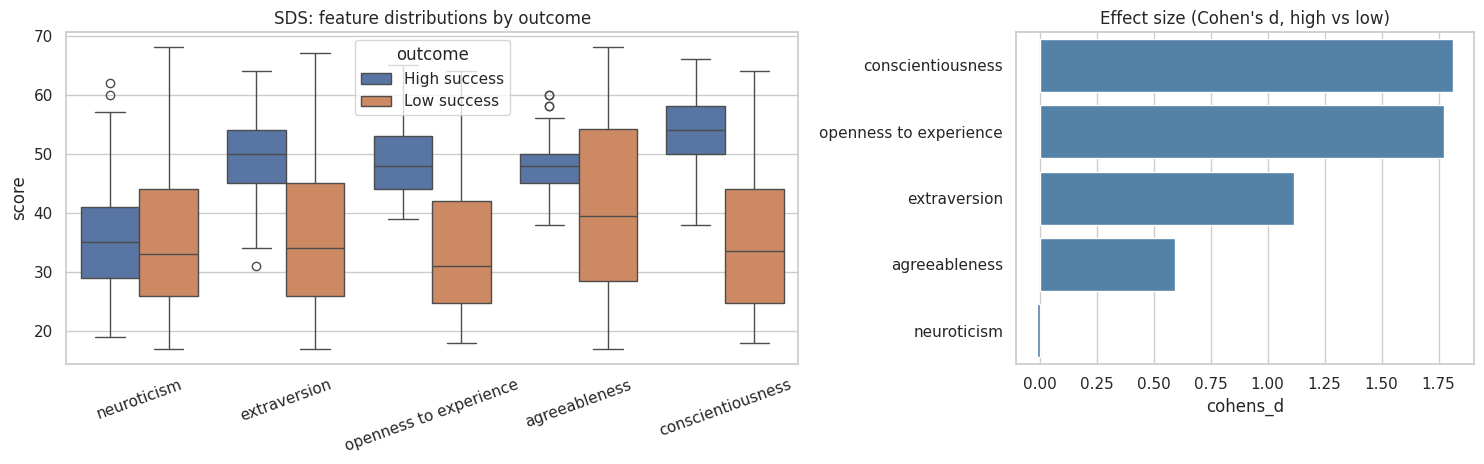

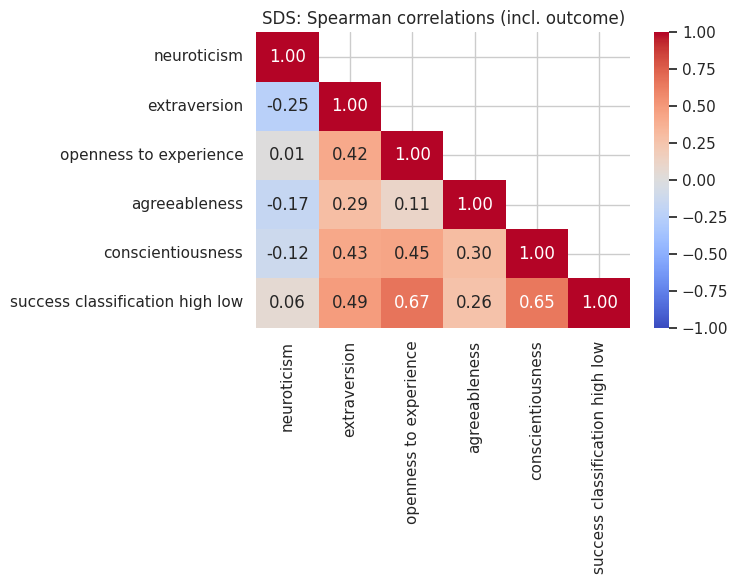

Direction check: if the 1-group has the higher means, the 1 = high assumption holds.


In [14]:
# ---- 6b. SDS ----
sds_effects = group_compare(sds_core, SDS_TRAITS, 'success_classification_high_low')
print('SDS: traits of high vs low success seniors'); display(sds_effects)
outcome_plots(sds_core, SDS_TRAITS, 'outcome', 'success_classification_high_low', 'SDS')
corr_heatmap(sds_core, SDS_TRAITS, 'success_classification_high_low', 'SDS')
print('Direction check: if the 1-group has the higher means, the 1 = high assumption holds.')

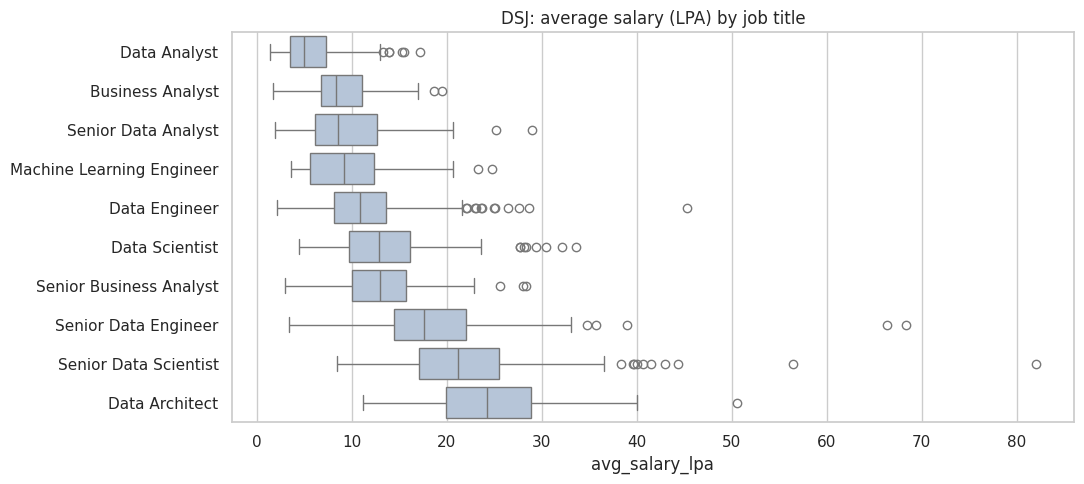

Kruskal-Wallis salary across titles: H=828.0, p=2.01e-172
Spearman min_experience vs avg salary: rho=0.63, p=3.88e-178

Median average salary (LPA) and senior premium by role family:


seniority,Junior/Mid,Senior,senior_premium_pct
role_family,,,
Business Analyst,8.300,13.000,56.627
Data Analyst,5.000,8.600,72.000
Data Architect,NaN,24.250,NaN
Data Engineer,10.850,17.600,62.212
Data Scientist,12.850,21.200,64.981
Machine Learning Engineer,9.150,NaN,NaN



Top 10 companies hold 35.5% of all openings


,total_openings
company_name,
TCS,9064
Accenture,5425
Cognizant,3813
Wipro,2566
IBM,2480
Genpact,2147
Capgemini,1994
L&T Infotech,1873
Tech Mahindra,1830


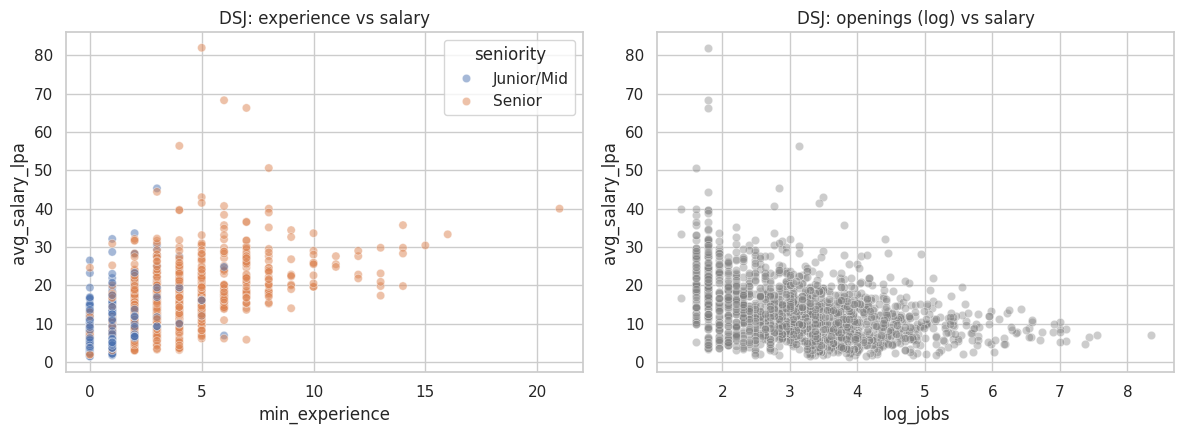

In [15]:
# ---- 6c. DataScience Jobs: what drives salary and demand ----
order = dsj_core.groupby('job_title').avg_salary_lpa.median().sort_values().index
plt.figure(figsize=(11, 5))
sns.boxplot(data=dsj_core, y='job_title', x='avg_salary_lpa', order=order, color='lightsteelblue')
plt.title('DSJ: average salary (LPA) by job title'); plt.ylabel('')
savefig('dsj_salary_by_title')

groups = [g.avg_salary_lpa.values for _, g in dsj_core.groupby('job_title')]
H, p = stats.kruskal(*groups)
rho, p_rho = stats.spearmanr(dsj_core.min_experience, dsj_core.avg_salary_lpa)
print(f'Kruskal-Wallis salary across titles: H={H:.1f}, p={p:.2e}')
print(f'Spearman min_experience vs avg salary: rho={rho:.2f}, p={p_rho:.2e}')

prem = dsj_core.pivot_table(index='role_family', columns='seniority', values='avg_salary_lpa', aggfunc='median')
if {'Junior/Mid', 'Senior'} <= set(prem.columns):
    prem['senior_premium_pct'] = (prem['Senior'] / prem['Junior/Mid'] - 1) * 100
print('\nMedian average salary (LPA) and senior premium by role family:')
dsj_premium = prem.copy(); display(dsj_premium)

openings = dsj_core.groupby('company_name').num_of_jobs.sum().sort_values(ascending=False)
print(f'\nTop 10 companies hold {openings.head(10).sum() / openings.sum():.1%} of all openings')
display(openings.head(10).to_frame('total_openings'))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=dsj_core, x='min_experience', y='avg_salary_lpa', hue='seniority', alpha=.5, ax=ax[0])
ax[0].set_title('DSJ: experience vs salary')
sns.scatterplot(data=dsj_core, x='log_jobs', y='avg_salary_lpa', alpha=.4, ax=ax[1], color='gray')
ax[1].set_title('DSJ: openings (log) vs salary')
savefig('dsj_experience_salary')

Spearman exp_min_yrs vs salary_min_lpa: rho=0.69, p=0.00e+00
Spearman exp_min_yrs vs salary_mid: rho=0.69, p=0.00e+00


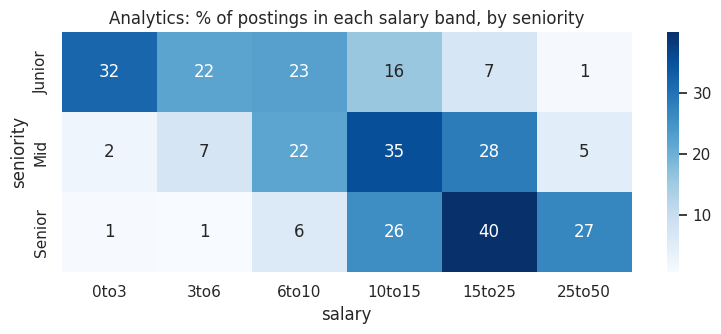

Salary midpoint (LPA) by role family (core data roles):


,count,median,mean
role_family,,,
Architect,357,20.000,19.604
Data Scientist,439,12.500,15.673
Data Engineer,446,12.500,14.258
ML/AI Engineer,201,12.500,17.786
Analyst,4007,8.000,10.871


Salary midpoint (LPA) by location group:


,count,median
location_group,,
Bengaluru,3813,12.500
Delhi NCR,1271,12.500
Mumbai,2401,12.500
Gurgaon,1533,8.000
Chennai,971,8.000
Hyderabad,983,8.000
Noida,542,8.000
Other,2153,8.000
Pune,1082,8.000


Salary-midpoint premium for postings mentioning each skill dimension (LPA, controlled by seniority bucket):


,share_postings,median_with,median_without,diff_overall,mannwhitney_p,diff_Junior,diff_Mid,diff_Senior
skill,,,,,,,,
big_data_skills,0.056,12.500,8.000,4.500,0.000,3.500,0.000,0.000
maths_stats_skills,0.128,12.500,8.000,4.500,0.000,3.500,0.000,0.000
coding_skills,0.240,12.500,8.000,4.500,0.000,3.500,0.000,0.000
ai_and_ml_skills,0.076,12.500,8.000,4.500,0.000,3.500,0.000,0.000
dashboard_and_storytelling_skills,0.071,8.000,12.500,-4.500,0.570,3.500,0.000,0.000


In [16]:
# ---- 6d. Analytics Jobs: salary, experience, location, skills ----
for a_, b_ in [('exp_min_yrs', 'salary_min_lpa'), ('exp_min_yrs', 'salary_mid')]:
    r_, p_ = stats.spearmanr(an_core[a_], an_core[b_])
    print(f'Spearman {a_} vs {b_}: rho={r_:.2f}, p={p_:.2e}')

ct = pd.crosstab(an_core.seniority, an_core.salary, normalize='index').reindex(index=['Junior', 'Mid', 'Senior'], columns=band_order) * 100
plt.figure(figsize=(8, 3.5))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='Blues'); plt.title('Analytics: % of postings in each salary band, by seniority')
savefig('an_seniority_salary_band')

role_sal = an_core[an_core.is_core_data_role == 1].groupby('role_family').salary_mid.agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
print('Salary midpoint (LPA) by role family (core data roles):'); display(role_sal)
loc_sal = an_core.groupby('location_group').salary_mid.agg(['count', 'median']).sort_values('median', ascending=False)
print('Salary midpoint (LPA) by location group:'); display(loc_sal)

rows = []
for k in SKILL_PATTERNS:
    col = f'skill_{k}'
    w, wo = an_core.loc[an_core[col] == 1, 'salary_mid'], an_core.loc[an_core[col] == 0, 'salary_mid']
    row = {'skill': k, 'share_postings': an_core[col].mean(), 'median_with': w.median(), 'median_without': wo.median(),
           'diff_overall': w.median() - wo.median(), 'mannwhitney_p': stats.mannwhitneyu(w, wo).pvalue}
    for s_ in ['Junior', 'Mid', 'Senior']:
        sub = an_core[an_core.seniority == s_]
        row[f'diff_{s_}'] = sub.loc[sub[col] == 1, 'salary_mid'].median() - sub.loc[sub[col] == 0, 'salary_mid'].median()
    rows.append(row)
skill_premium = pd.DataFrame(rows).set_index('skill')
print('Salary-midpoint premium for postings mentioning each skill dimension (LPA, controlled by seniority bucket):')
display(skill_premium)

## 7. Consolidation — the bridge layer
This is where four unrelated files become one story, using **shared constructs** instead of keys:
- **Seniority:** JDS = junior supply, SDS = senior supply, both job files carry seniority via title or experience.
- **Skills:** the five JDS dimensions are re-found in the Analytics postings.
- **Reward:** salary hike (JDS) is set against salary levels and premiums in the job files.
- **Personality (proxy):** SDS traits are set against soft-skill language in senior postings (exploratory).

,dsj_rows,dsj_median_salary,dsj_median_min_exp,dsj_openings,an_postings,an_median_salary_mid,an_median_min_exp
seniority,,,,,,,
Junior/Mid,803.000,9.300,1.000,"68,797.000",NaN,NaN,NaN
Senior,792.000,15.500,4.000,"24,008.000","2,527.000",20.000,10.000
Junior,NaN,NaN,NaN,NaN,"7,509.000",4.500,2.000
Mid,NaN,NaN,NaN,NaN,"4,713.000",12.500,5.000


Share of postings mentioning each skill dimension:


all_postings              core_data_roles             
seniority                               Junior   Mid Senior          Junior   Mid Senior
big_data_skills                          0.039 0.074  0.074           0.077 0.144  0.169
maths_stats_skills                       0.118 0.142  0.129           0.194 0.212  0.219
coding_skills                            0.217 0.294  0.207           0.280 0.373  0.345
ai_and_ml_skills                         0.067 0.091  0.077           0.144 0.183  0.170
dashboard_and_storytelling_skills        0.071 0.082  0.055           0.106 0.119  0.068

,jds_cohens_d,jds_auc_single,demand_all,demand_junior,salary_premium_junior_LPA,effect_rank,demand_rank,rank_gap
big_data_skills,0.223,0.561,0.056,0.039,3.500,5.000,5.000,0.000
maths_stats_skills,1.202,0.775,0.128,0.118,3.500,2.000,2.000,0.000
coding_skills,0.976,0.744,0.240,0.217,3.500,3.000,1.000,-2.000
ai_and_ml_skills,0.863,0.682,0.076,0.067,3.500,4.000,4.000,0.000
dashboard_and_storytelling_skills,1.302,0.794,0.071,0.071,3.500,1.000,3.000,2.000


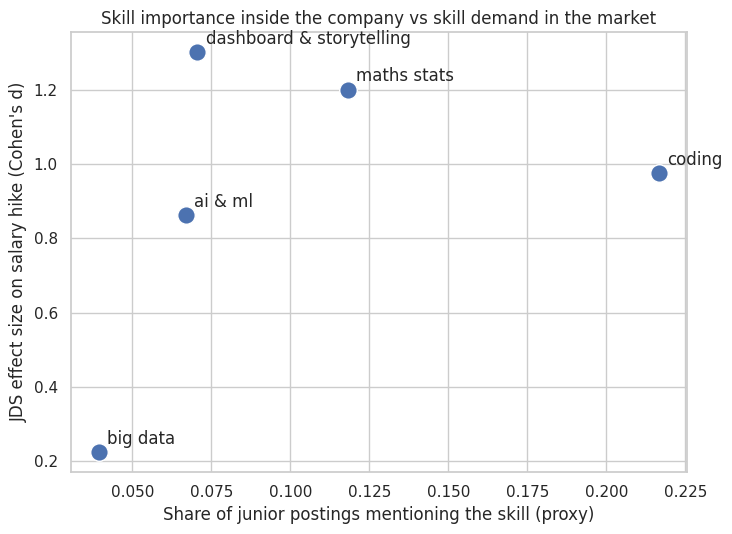

Caution: demand shares are keyword proxies on truncated text; treat the gap as a hypothesis to test, not a conclusion.


In [17]:
# ---- 7a. Market by seniority, side by side ----
mk_dsj = dsj_core.groupby('seniority').agg(dsj_rows=('job_title', 'size'), dsj_median_salary=('avg_salary_lpa', 'median'),
                                          dsj_median_min_exp=('min_experience', 'median'), dsj_openings=('num_of_jobs', 'sum'))
mk_an = an_core.groupby('seniority').agg(an_postings=('s_no', 'size'), an_median_salary_mid=('salary_mid', 'median'),
                                        an_median_min_exp=('exp_min_yrs', 'median'))
market_by_seniority = pd.concat([mk_dsj, mk_an], axis=1)
display(market_by_seniority)

# ---- 7b. Skill demand by seniority (all postings and core data roles) ----
skill_cols = [f'skill_{k}' for k in SKILL_PATTERNS]
dem_all  = an_core.groupby('seniority')[skill_cols].mean().T.rename(index=lambda s: s.replace('skill_', ''))
dem_core = an_core[an_core.is_core_data_role == 1].groupby('seniority')[skill_cols].mean().T.rename(index=lambda s: s.replace('skill_', ''))
skill_demand_by_seniority = pd.concat({'all_postings': dem_all, 'core_data_roles': dem_core}, axis=1)
print('Share of postings mentioning each skill dimension:'); display(skill_demand_by_seniority)

# ---- 7c. Skill alignment table: what predicts junior success vs what the market asks for and pays ----
alignment = pd.DataFrame({
    'jds_cohens_d':      jds_effects.cohens_d,
    'jds_auc_single':    jds_effects.auc_single,
    'demand_all':        an_core[skill_cols].mean().rename(lambda s: s.replace('skill_', '')),
    'demand_junior':     an_core[an_core.seniority == 'Junior'][skill_cols].mean().rename(lambda s: s.replace('skill_', '')),
    'salary_premium_junior_LPA': skill_premium.diff_Junior,
}).loc[JDS_SKILLS]
alignment['effect_rank'] = alignment.jds_cohens_d.rank(ascending=False)
alignment['demand_rank'] = alignment.demand_junior.rank(ascending=False)
alignment['rank_gap'] = alignment.demand_rank - alignment.effect_rank   # >0 : matters for outcomes more than postings suggest
display(alignment)

plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=alignment.reset_index(), x='demand_junior', y='jds_cohens_d', s=160)
for k, r in alignment.iterrows():
    plt.annotate(pretty(k), (r.demand_junior, r.jds_cohens_d), xytext=(6, 6), textcoords='offset points')
plt.xlabel('Share of junior postings mentioning the skill (proxy)'); plt.ylabel("JDS effect size on salary hike (Cohen's d)")
plt.title('Skill importance inside the company vs skill demand in the market')
savefig('skill_alignment_scatter')
print('Caution: demand shares are keyword proxies on truncated text; treat the gap as a hypothesis to test, not a conclusion.')

In [18]:
# ---- 7d. Personality proxy bridge (exploratory) ----
SOFT_PATTERNS = {
    'extraversion':           r'communicat|stakeholder|client|customer|presentation|interpersonal',
    'conscientiousness':      r'attention to detail|detail[- ]oriented|accura|deadline|ownership|organi[sz]ed|quality',
    'openness_to_experience': r'innovat|creativ|curious|research|learn|explor',
    'agreeableness':          r'team player|collaborat|cooperat|teamwork|supportive',
    'neuroticism':            r'pressure|stress|fast[- ]paced|resilien',
}
desc = an_core[an_core.job_description.notna()]
dtext = desc.job_description.str.lower()
soft = pd.DataFrame({k: dtext.str.contains(p, regex=True).astype(int) for k, p in SOFT_PATTERNS.items()}, index=desc.index)
soft['seniority'] = desc.seniority
soft_by_sen = soft.groupby('seniority').mean().T.reindex(SDS_TRAITS)
bridge_personality = pd.concat([sds_effects.cohens_d.reindex(SDS_TRAITS).rename('sds_cohens_d'), soft_by_sen], axis=1)
print(f'Soft-skill language in postings with a description (n={len(desc):,}); proxy mapping is an assumption:')
display(bridge_personality)

Soft-skill language in postings with a description (n=11,460); proxy mapping is an assumption:


,sds_cohens_d,Junior,Mid,Senior
neuroticism,-0.012,0.005,0.006,0.006
extraversion,1.115,0.156,0.133,0.115
openness_to_experience,1.774,0.075,0.051,0.033
agreeableness,0.595,0.014,0.012,0.013
conscientiousness,1.815,0.025,0.018,0.018


## 8. Multivariate structure — PCA and clustering of profiles

JDS: explained variance


,share
PC1,0.408
PC2,0.215
PC3,0.160
PC4,0.124
PC5,0.094


JDS: loadings (PC1-PC3)


,PC1,PC2,PC3
big data,-0.026,0.903,0.237
maths stats,0.540,-0.206,-0.169
coding,0.509,0.193,-0.550
ai & ml,0.438,-0.207,0.779
dashboard & storytelling,0.506,0.251,0.073


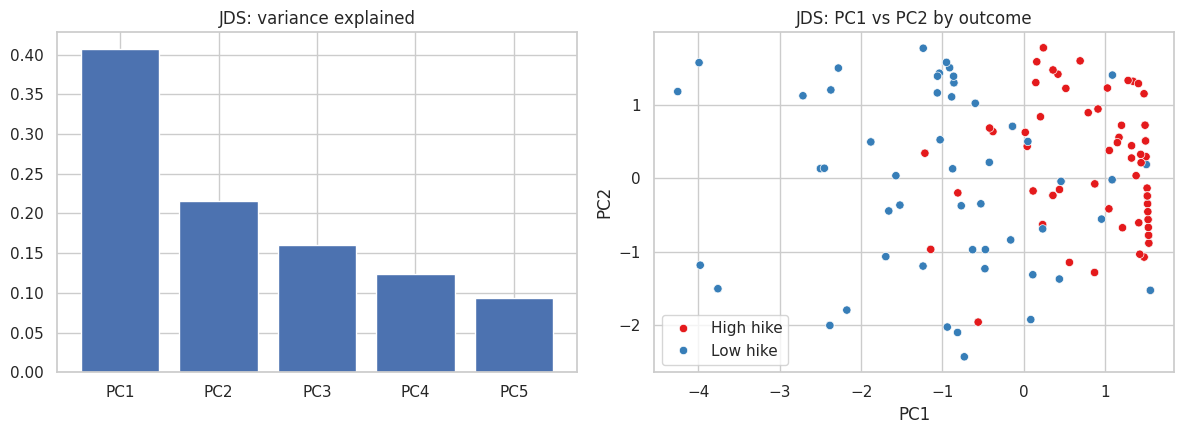

JDS: silhouette by k -> {2: np.float64(0.333), 3: np.float64(0.337), 4: np.float64(0.283), 5: np.float64(0.263), 6: np.float64(0.315)} | chosen k=3
JDS: cluster profiles (pct_high = % in the high-outcome group)


,big_data_skills,maths_stats_skills,coding_skills,ai_and_ml_skills,dashboard_and_storytelling_skills,n,pct_high
cluster,,,,,,,
0,3.813,3.639,3.970,3.230,3.691,23,4.348
1,3.831,4.721,4.815,4.827,4.877,78,83.333
2,3.911,3.813,3.326,4.839,3.687,38,18.421


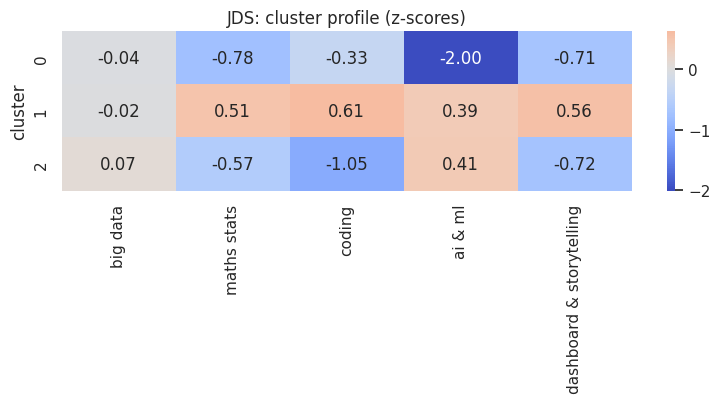

SDS: explained variance


,share
PC1,0.413
PC2,0.210
PC3,0.167
PC4,0.115
PC5,0.096


SDS: loadings (PC1-PC3)


,PC1,PC2,PC3
neuroticism,-0.247,0.766,0.483
extraversion,0.533,-0.040,-0.227
openness to experience,0.471,0.513,-0.229
agreeableness,0.374,-0.341,0.810
conscientiousness,0.541,0.178,0.083


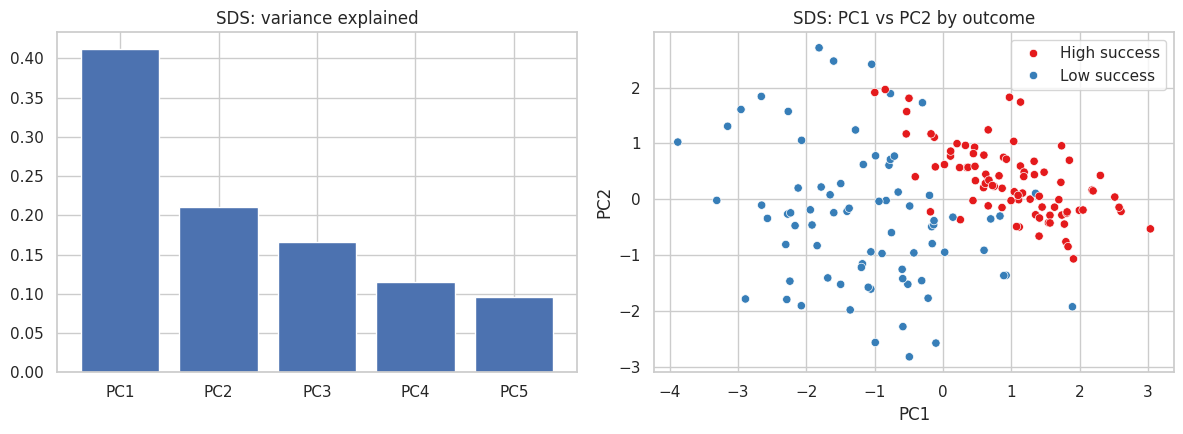

SDS: silhouette by k -> {2: np.float64(0.313), 3: np.float64(0.322), 4: np.float64(0.335), 5: np.float64(0.212), 6: np.float64(0.216)} | chosen k=4
SDS: cluster profiles (pct_high = % in the high-outcome group)


,neuroticism,extraversion,openness_to_experience,agreeableness,conscientiousness,n,pct_high
cluster,,,,,,,
0,54.818,36.136,42.182,34.545,35.682,22,27.273
1,35.950,36.500,27.250,58.600,34.050,20,0.000
2,33.820,49.517,47.955,48.225,53.674,89,88.764
3,29.733,34.133,30.433,31.900,34.533,30,0.000


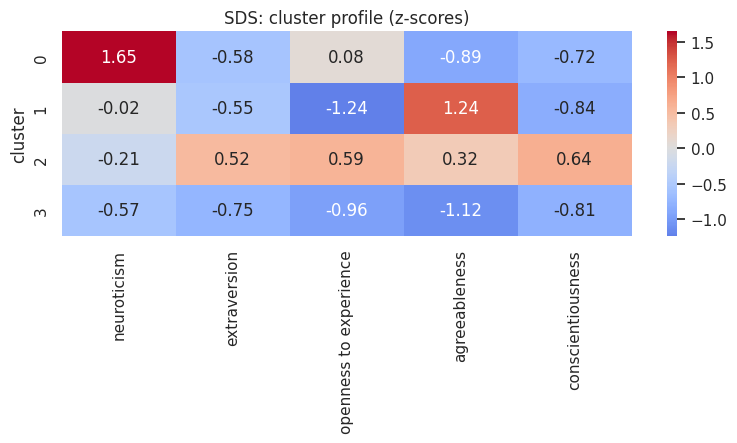

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def pca_block(df, cols, target_col, tag):
    Z = StandardScaler().fit_transform(df[cols])
    pca = PCA(random_state=RANDOM_STATE).fit(Z)
    sc = pca.transform(Z)
    evr = pd.Series(pca.explained_variance_ratio_, index=[f'PC{i + 1}' for i in range(len(cols))])
    load = pd.DataFrame(pca.components_.T, index=[pretty(c) for c in cols], columns=evr.index)
    print(f'{tag}: explained variance'); display(evr.to_frame('share'))
    print(f'{tag}: loadings (PC1-PC3)'); display(load.iloc[:, :3])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].bar(evr.index, evr.values); ax[0].set_title(f'{tag}: variance explained')
    sns.scatterplot(x=sc[:, 0], y=sc[:, 1], hue=df[target_col].values, ax=ax[1], palette='Set1')
    ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2'); ax[1].set_title(f'{tag}: PC1 vs PC2 by outcome')
    savefig(f'{tag.lower()}_pca')

def cluster_block(df, cols, outcome_col, tag, k_range=range(2, 7)):
    Z = StandardScaler().fit_transform(df[cols])
    sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)) for k in k_range}
    best_k = max(sil, key=sil.get)
    print(f'{tag}: silhouette by k ->', {k: round(v, 3) for k, v in sil.items()}, f'| chosen k={best_k}')
    labels = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    out = df.copy(); out['cluster'] = labels
    prof = out.groupby('cluster')[cols].mean(); prof['n'] = out.groupby('cluster').size(); prof['pct_high'] = out.groupby('cluster')[outcome_col].mean() * 100
    print(f'{tag}: cluster profiles (pct_high = % in the high-outcome group)'); display(prof)
    plt.figure(figsize=(8, 3 + 0.4 * best_k))
    zprof = (out.groupby('cluster')[cols].mean() - df[cols].mean()) / df[cols].std()
    sns.heatmap(zprof.rename(columns=pretty), annot=True, fmt='.2f', cmap='coolwarm', center=0); plt.title(f'{tag}: cluster profile (z-scores)')
    savefig(f'{tag.lower()}_clusters')
    return labels

pca_block(jds_core, JDS_SKILLS, 'outcome', 'JDS')
jds_core['cluster'] = cluster_block(jds_core, JDS_SKILLS, 'salary_hike_high_or_low', 'JDS')
pca_block(sds_core, SDS_TRAITS, 'outcome', 'SDS')
sds_core['cluster'] = cluster_block(sds_core, SDS_TRAITS, 'success_classification_high_low', 'SDS')

## 9. Predictive baselines
Small samples (139 and 161 rows) mean **repeated stratified cross-validation**, simple models, and a majority-class baseline. Sensitivity checks re-run the logistic model without flagged rows.

In [20]:
from sklearn.model_selection import RepeatedStratifiedKFold, KFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def eval_classifier(X, y, label):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
    models = {
        'Baseline (majority)':     DummyClassifier(strategy='most_frequent'),
        'Logistic (standardised)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        'Decision tree (depth 3)': DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        'Random forest':           RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    }
    rows = []
    for n, m in models.items():
        r = cross_validate(m, X, y, cv=cv, scoring={'auc': 'roc_auc', 'acc': 'accuracy'}, n_jobs=-1)
        rows.append({'model': n, 'cv_auc': r['test_auc'].mean(), 'auc_sd': r['test_auc'].std(), 'cv_accuracy': r['test_acc'].mean()})
    res = pd.DataFrame(rows).set_index('model')
    print(f'{label}: repeated 5-fold CV (10 repeats)'); display(res)
    return res

def explain_classifier(X, y, label):
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X, y)
    coef = pd.DataFrame({'std_coef': lr[-1].coef_[0], 'odds_ratio_per_1sd': np.exp(lr[-1].coef_[0])}, index=X.columns).sort_values('std_coef', ascending=False)
    print(f'{label}: logistic coefficients (per 1 SD)'); display(coef)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    pi = permutation_importance(rf, Xte, yte, n_repeats=50, random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.DataFrame({'perm_importance': pi.importances_mean, 'sd': pi.importances_std}, index=X.columns).sort_values('perm_importance', ascending=False)
    print(f'{label}: random-forest permutation importance (30% hold-out)'); display(imp)
    tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X, y)
    print(f'{label}: depth-3 tree rules'); print(export_text(tree, feature_names=list(X.columns)))
    return coef, imp

def quick_auc(X, y):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
    return cross_validate(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X, y, cv=cv, scoring='roc_auc')['test_score'].mean()

# ---- JDS ----
Xj, yj = jds_core[JDS_SKILLS], jds_core.salary_hike_high_or_low
jds_cv = eval_classifier(Xj, yj, 'JDS: predict high salary hike')
jds_coef, jds_imp = explain_classifier(Xj, yj, 'JDS')
clean_j = jds_core[['flag_id_collision', 'flag_repeat_score_profile', 'flag_outlier_z3']].sum(axis=1) == 0
print(f'JDS sensitivity: logistic AUC all rows={quick_auc(Xj, yj):.3f} | excluding flagged rows (n={clean_j.sum()})={quick_auc(Xj[clean_j], yj[clean_j]):.3f}')

JDS: predict high salary hike: repeated 5-fold CV (10 repeats)


,cv_auc,auc_sd,cv_accuracy
model,,,
Baseline (majority),0.500,0.000,0.525
Logistic (standardised),0.903,0.053,0.857
Decision tree (depth 3),0.800,0.082,0.782
Random forest,0.875,0.059,0.824


JDS: logistic coefficients (per 1 SD)


,std_coef,odds_ratio_per_1sd
maths_stats_skills,1.284,3.612
dashboard_and_storytelling_skills,1.117,3.057
ai_and_ml_skills,0.762,2.143
big_data_skills,0.683,1.980
coding_skills,0.533,1.704


JDS: random-forest permutation importance (30% hold-out)


,perm_importance,sd
maths_stats_skills,0.091,0.038
dashboard_and_storytelling_skills,0.085,0.034
ai_and_ml_skills,0.030,0.026
big_data_skills,0.009,0.012
coding_skills,0.005,0.018


JDS: depth-3 tree rules
|--- dashboard_and_storytelling_skills <= 4.15
|   |--- maths_stats_skills <= 4.60
|   |   |--- class: 0
|   |--- maths_stats_skills >  4.60
|   |   |--- dashboard_and_storytelling_skills <= 2.55
|   |   |   |--- class: 0
|   |   |--- dashboard_and_storytelling_skills >  2.55
|   |   |   |--- class: 0
|--- dashboard_and_storytelling_skills >  4.15
|   |--- maths_stats_skills <= 3.55
|   |   |--- class: 0
|   |--- maths_stats_skills >  3.55
|   |   |--- coding_skills <= 4.65
|   |   |   |--- class: 1
|   |   |--- coding_skills >  4.65
|   |   |   |--- class: 1

JDS sensitivity: logistic AUC all rows=0.903 | excluding flagged rows (n=113)=0.875


In [21]:
# ---- SDS ----
Xs, ys = sds_core[SDS_TRAITS], sds_core.success_classification_high_low
sds_cv = eval_classifier(Xs, ys, 'SDS: predict high success')
sds_coef, sds_imp = explain_classifier(Xs, ys, 'SDS')
clean_s = sds_core[['flag_id_collision', 'flag_repeat_score_profile', 'flag_outlier_z3']].sum(axis=1) == 0
print(f'SDS sensitivity: logistic AUC all rows={quick_auc(Xs, ys):.3f} | excluding flagged rows (n={clean_s.sum()})={quick_auc(Xs[clean_s], ys[clean_s]):.3f}')

SDS: predict high success: repeated 5-fold CV (10 repeats)


,cv_auc,auc_sd,cv_accuracy
model,,,
Baseline (majority),0.500,0.000,0.528
Logistic (standardised),0.964,0.033,0.927
Decision tree (depth 3),0.942,0.039,0.934
Random forest,0.996,0.008,0.949


SDS: logistic coefficients (per 1 SD)


,std_coef,odds_ratio_per_1sd
conscientiousness,2.094,8.114
openness_to_experience,2.043,7.717
extraversion,0.954,2.595
neuroticism,0.798,2.222
agreeableness,0.628,1.873


SDS: random-forest permutation importance (30% hold-out)


,perm_importance,sd
openness_to_experience,0.081,0.035
conscientiousness,0.044,0.021
agreeableness,0.021,0.009
extraversion,0.006,0.008
neuroticism,0.003,0.002


SDS: depth-3 tree rules
|--- openness_to_experience <= 38.50
|   |--- class: 0
|--- openness_to_experience >  38.50
|   |--- conscientiousness <= 36.50
|   |   |--- class: 0
|   |--- conscientiousness >  36.50
|   |   |--- agreeableness <= 37.50
|   |   |   |--- class: 0
|   |   |--- agreeableness >  37.50
|   |   |   |--- class: 1

SDS sensitivity: logistic AUC all rows=0.964 | excluding flagged rows (n=143)=0.955


In [22]:
# ---- Salary models for the two job files (regression baselines) ----
def eval_regressor(df, num_cols, cat_cols, target, label, log_target=False):
    X = df[num_cols + cat_cols]
    y = np.log(df[target]) if log_target else df[target]
    pre = ColumnTransformer([('num', 'passthrough', num_cols),
                             ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)])
    models = {
        'Baseline (mean)':   DummyRegressor(),
        'Ridge':             make_pipeline(pre, StandardScaler(), Ridge(alpha=1.0)),
        'Gradient boosting': make_pipeline(pre, HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for n, m in models.items():
        r = cross_validate(m, X, y, cv=cv, scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'})
        rows.append({'model': n, 'cv_r2': r['test_r2'].mean(), 'cv_mae': -r['test_mae'].mean()})
    print(f'{label} (target={"log " if log_target else ""}{target})'); display(pd.DataFrame(rows).set_index('model'))
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
    gb = models['Gradient boosting'].fit(Xtr, ytr)
    pi = permutation_importance(gb, Xte, yte, n_repeats=10, random_state=RANDOM_STATE, scoring='r2')
    display(pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).to_frame('permutation_importance (R2 drop)'))

eval_regressor(dsj_core, ['min_experience', 'is_senior_title', 'log_jobs', 'large_recruiter'], ['role_family'],
               'avg_salary_lpa', 'DataScience Jobs salary model', log_target=True)

an_num_feats = ['exp_min_yrs', 'is_metro', 'n_skill_dims'] + skill_cols
eval_regressor(an_core, an_num_feats, ['role_family', 'location_group'], 'salary_mid', 'Analytics Jobs salary model')
print('Read these as descriptive drivers of advertised salary, not causal effects.')

DataScience Jobs salary model (target=log avg_salary_lpa)


,cv_r2,cv_mae
model,,
Baseline (mean),-0.002,0.487
Ridge,0.571,0.305
Gradient boosting,0.552,0.311


,permutation_importance (R2 drop)
min_experience,0.504
role_family,0.435
log_jobs,0.044
is_senior_title,0.018
large_recruiter,0.004


Analytics Jobs salary model (target=salary_mid)


,cv_r2,cv_mae
model,,
Baseline (mean),-0.001,6.972
Ridge,0.439,5.022
Gradient boosting,0.444,4.989


,permutation_importance (R2 drop)
exp_min_yrs,0.798
role_family,0.021
location_group,0.014
skill_ai_and_ml_skills,0.004
n_skill_dims,0.004
skill_maths_stats_skills,0.003
is_metro,0.001
skill_coding_skills,0.000
skill_dashboard_and_storytelling_skills,0.000
skill_big_data_skills,-0.000


Read these as descriptive drivers of advertised salary, not causal effects.


## 10. Export — analysis-ready tables, figures, and a zip

In [23]:
exports = {
    'jds_core': jds_core, 'sds_core': sds_core, 'dsj_core': dsj_core,
    'analytics_core_no_text': an_core.drop(columns=['job_description']),   # smaller file; text not needed downstream
    'bridge_market_by_seniority': market_by_seniority.reset_index(),
    'bridge_skill_demand_by_seniority': skill_demand_by_seniority.reset_index(),
    'bridge_skill_alignment': alignment.reset_index(),
    'bridge_personality_proxy': bridge_personality.reset_index(),
    'table_jds_effects': jds_effects.reset_index(),
    'table_sds_effects': sds_effects.reset_index(),
    'table_skill_salary_premium': skill_premium.reset_index(),
    'table_dsj_senior_premium': dsj_premium.reset_index(),
}
for name, df in exports.items():
    df.to_csv(os.path.join(OUT_DIR, f'{name}.csv'), index=False)

shutil.make_archive('dd_foundation_outputs', 'zip', OUT_DIR)
print('Saved', len(exports), 'tables +', len(os.listdir(FIG_DIR)), 'figures to', OUT_DIR, '-> dd_foundation_outputs.zip')
if IN_COLAB:
    colab_files.download('dd_foundation_outputs.zip')

Saved 12 tables + 17 figures to outputs -> dd_foundation_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# ---- one-screen recap, computed from the objects above ----
top_skill = jds_effects.cohens_d.idxmax(); top_trait = sds_effects.cohens_d.idxmax(); flat_trait = sds_effects.cohens_d.abs().idxmin()
print('=' * 78); print('FOUNDATION RECAP'); print('=' * 78)
print(f'Core rows -> JDS {len(jds_core)}, SDS {len(sds_core)}, DS Jobs {len(dsj_core)}, Analytics {len(an_core):,}')
print(f'Strongest junior skill signal : {pretty(top_skill)} (d={jds_effects.cohens_d.max():.2f})')
print(f'Strongest senior trait signal : {pretty(top_trait)} (d={sds_effects.cohens_d.max():.2f}); weakest: {pretty(flat_trait)} (d={sds_effects.cohens_d[flat_trait]:.2f})')
print(f'JDS model CV AUC (logistic) {jds_cv.loc["Logistic (standardised)", "cv_auc"]:.2f} | SDS {sds_cv.loc["Logistic (standardised)", "cv_auc"]:.2f}')
if 'senior_premium_pct' in dsj_premium:
    print(f'Median senior salary premium across role families: {dsj_premium.senior_premium_pct.median():.0f}%')
gap = alignment.rank_gap.idxmax()
print(f'Largest importance-vs-demand gap: {pretty(gap)} (rank gap {alignment.rank_gap.max():+.0f})')

FOUNDATION RECAP
Core rows -> JDS 139, SDS 161, DS Jobs 1595, Analytics 14,749
Strongest junior skill signal : dashboard & storytelling (d=1.30)
Strongest senior trait signal : conscientiousness (d=1.81); weakest: neuroticism (d=-0.01)
JDS model CV AUC (logistic) 0.90 | SDS 0.96
Median senior salary premium across role families: 64%
Largest importance-vs-demand gap: dashboard & storytelling (rank gap +2)


## Where to go from here
1. Pick the objective (for example *talent-market alignment by career stage*) and keep sections 7–9 as the core of the analysis chapter.
2. Tighten the skill dictionaries in section 4 (check a sample of postings by hand) and report keyword coverage.
3. Add objective-specific modelling on top of the exported `bridge_*` tables.
4. State the limitations explicitly: no row-level linkage, single-company trait samples, keyword proxies on truncated text, associational results only.